# Memory comparison: ffocp_eq vs cvxpylayer

This notebook compares the peak RSS (Resident Set Size) memory usage between `ffocp_eq` and `cvxpylayer` across problem sizes.

- batch_size = 8
- ydim ∈ {100, 200, …, 1000}
- Only **one iteration** per ydim (first batch forward + backward)


In [3]:
import os
import sys
import time
import gc

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

# Add synthetic_task directory directly to path (no __init__.py in that folder)
sys.path.insert(0, os.path.join(os.path.abspath('.'), 'synthetic_task'))

from models import OptModel
from data import genData
from utils_synthetic import PeakRSS, bytes_to_gb

In [4]:
# Configuration
BATCH_SIZE = 8
SEED = 3
INPUT_DIM = 640
YDIM_LIST = list(range(100, 1001, 100))
NUM_SAMPLES = 2000
LEARNING_RATE = 0.001

# Hyperparameters for ffocp_eq
ALPHA = 100
DUAL_CUTOFF = 1e-3
SLACK_TOL = 1e-8
BACKWARD_EPS = 1e-3

# Device
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")
print(f"ydim values to benchmark: {YDIM_LIST}")

Using device: cpu
ydim values to benchmark: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]


In [5]:
def set_seed(seed):
    """Set random seeds for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

def cleanup():
    """Clean up memory"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [4]:
def benchmark_method(method_name, ydim):
    """
    Benchmark a single method for initialization and first iteration peak RSS.
    
    Args:
        method_name: 'ffocp_eq' or 'cvxpylayer'
        ydim: dimension of the optimization variable
    
    Returns:
        dict: Contains init_peak_rss, forward_peak_rss, backward_peak_rss (all in GB)
    """
    cleanup()
    set_seed(SEED)
    
    results = {'ydim': ydim, 'method': method_name}
    
    # Generate data
    train_loader, test_loader = genData(device, INPUT_DIM, ydim, NUM_SAMPLES, BATCH_SIZE)
    
    # Measure initialization peak RSS
    with PeakRSS(include_children=True, interval=0.0001) as m_init:
        model = OptModel(
            INPUT_DIM, ydim, 
            layer_type=method_name, 
            constraint_learnable=False, 
            batch_size=BATCH_SIZE, 
            device=device, 
            alpha=ALPHA, 
            dual_cutoff=DUAL_CUTOFF, 
            slack_tol=SLACK_TOL, 
            backward_eps=BACKWARD_EPS, 
            is_QP=True
        ).to(device)
    
    results['init_peak_rss_gb'] = bytes_to_gb(m_init.peak)
    
    # Setup optimizer and loss
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0)
    loss_fn = torch.nn.MSELoss()
    
    # Get first batch
    x, y = next(iter(train_loader))
    
    model.train()
    
    # Measure forward pass peak RSS
    with PeakRSS(include_children=True, interval=0.0001) as m_fwd:
        start_fwd = time.time()
        z, y_pred = model(x)
        forward_time = time.time() - start_fwd
    
    results['forward_peak_rss_gb'] = bytes_to_gb(m_fwd.peak)
    results['forward_time'] = forward_time
    
    # Compute loss
    ts_loss = loss_fn(y_pred, y)
    df_loss = torch.mean(y * z)
    loss = df_loss
    
    # Measure backward pass peak RSS
    with PeakRSS(include_children=True, interval=0.0001) as m_bwd:
        start_bwd = time.time()
        loss.backward()
        backward_time = time.time() - start_bwd
    
    results['backward_peak_rss_gb'] = bytes_to_gb(m_bwd.peak)
    results['backward_time'] = backward_time
    results['total_iter_time'] = forward_time + backward_time
    
    # Cleanup
    del model, optimizer, train_loader, test_loader
    cleanup()
    
    return results

## Run Benchmarks for All ydim Values

In [5]:
# Run benchmarks for all ydim values
all_results = []

for ydim in YDIM_LIST:
    print(f"\n{'='*60}")
    print(f"Benchmarking ydim={ydim}")
    print(f"{'='*60}")
    
    # Benchmark ffocp_eq
    print(f"  Running ffocp_eq...")
    ffocp_result = benchmark_method('ffocp_eq', ydim)
    all_results.append(ffocp_result)
    print(f"    Init RSS: {ffocp_result['init_peak_rss_gb']:.4f} GB, "
          f"Forward RSS: {ffocp_result['forward_peak_rss_gb']:.4f} GB, "
          f"Backward RSS: {ffocp_result['backward_peak_rss_gb']:.4f} GB")
    
    # Benchmark cvxpylayer
    print(f"  Running cvxpylayer...")
    cvxpy_result = benchmark_method('cvxpylayer', ydim)
    all_results.append(cvxpy_result)
    print(f"    Init RSS: {cvxpy_result['init_peak_rss_gb']:.4f} GB, "
          f"Forward RSS: {cvxpy_result['forward_peak_rss_gb']:.4f} GB, "
          f"Backward RSS: {cvxpy_result['backward_peak_rss_gb']:.4f} GB")

print(f"\n{'='*60}")
print("All benchmarks completed!")
print(f"{'='*60}")


Benchmarking ydim=100
  Running ffocp_eq...
FFOLayer forward eps = 1e-12, backward eps = 0.001
max_workers: 8
    Init RSS: 0.3490 GB, Forward RSS: 0.3977 GB, Backward RSS: 0.4037 GB
  Running cvxpylayer...


/nethome/zzhao628/anaconda3/envs/bilevel/lib/python3.10/site-packages/cvxpy/reductions/solvers/solving_chain.py:250: UserWarning: Your problem has too many parameters for efficient DPP compilation. We suggest setting 'ignore_dpp = True'.
  warnings.warn(


    Init RSS: 0.5497 GB, Forward RSS: 0.5671 GB, Backward RSS: 0.5808 GB

Benchmarking ydim=200
  Running ffocp_eq...
FFOLayer forward eps = 1e-12, backward eps = 0.001
max_workers: 8
    Init RSS: 0.5896 GB, Forward RSS: 0.5896 GB, Backward RSS: 0.5945 GB
  Running cvxpylayer...
    Init RSS: 1.2633 GB, Forward RSS: 1.2686 GB, Backward RSS: 1.3053 GB

Benchmarking ydim=300
  Running ffocp_eq...
FFOLayer forward eps = 1e-12, backward eps = 0.001
max_workers: 8
    Init RSS: 1.3261 GB, Forward RSS: 1.3312 GB, Backward RSS: 1.3318 GB
  Running cvxpylayer...
    Init RSS: 2.6546 GB, Forward RSS: 2.6542 GB, Backward RSS: 2.7367 GB

Benchmarking ydim=400
  Running ffocp_eq...
FFOLayer forward eps = 1e-12, backward eps = 0.001
max_workers: 8
    Init RSS: 2.7676 GB, Forward RSS: 2.7676 GB, Backward RSS: 2.7688 GB
  Running cvxpylayer...
    Init RSS: 4.3196 GB, Forward RSS: 4.3207 GB, Backward RSS: 4.5112 GB

Benchmarking ydim=500
  Running ffocp_eq...
FFOLayer forward eps = 1e-12, backward 

## Results Table

In [5]:
df = pd.read_csv('peakrss_benchmark_results.csv')

# Pivot for easier comparison
df_ffocp = df[df['method'] == 'ffocp_eq'].set_index('ydim')
df_cvxpy = df[df['method'] == 'cvxpylayer'].set_index('ydim')

# Display full results table
print("Full Results:")
df

Full Results:


,ydim,method,init_peak_rss_gb,forward_peak_rss_gb,forward_time,backward_peak_rss_gb,backward_time,total_iter_time
0,100,ffocp_eq,0.562920,0.652424,0.337005,0.675358,0.204346,0.541352
1,100,cvxpylayer,0.704193,0.778027,0.166445,0.781296,0.028233,0.194678
2,200,ffocp_eq,0.564537,0.672375,0.209352,0.690907,0.184464,0.393817
3,200,cvxpylayer,0.966274,0.737301,0.263529,0.763065,0.049828,0.313357
4,300,ffocp_eq,0.564751,0.677315,0.255209,0.732018,0.236742,0.491951
5,300,cvxpylayer,1.952305,0.906479,0.686642,0.950520,0.103317,0.789960
6,400,ffocp_eq,0.566673,0.728924,0.361483,0.787350,0.331312,0.692795
7,400,cvxpylayer,4.026390,1.370781,1.072643,1.432758,0.182669,1.255312
8,500,ffocp_eq,0.569153,0.814888,0.530983,0.860821,0.509320,1.040303
9,500,cvxpylayer,7.714897,2.415863,1.835934,2.506645,0.265122,2.101056


## Visualization: Peak RSS vs ydim

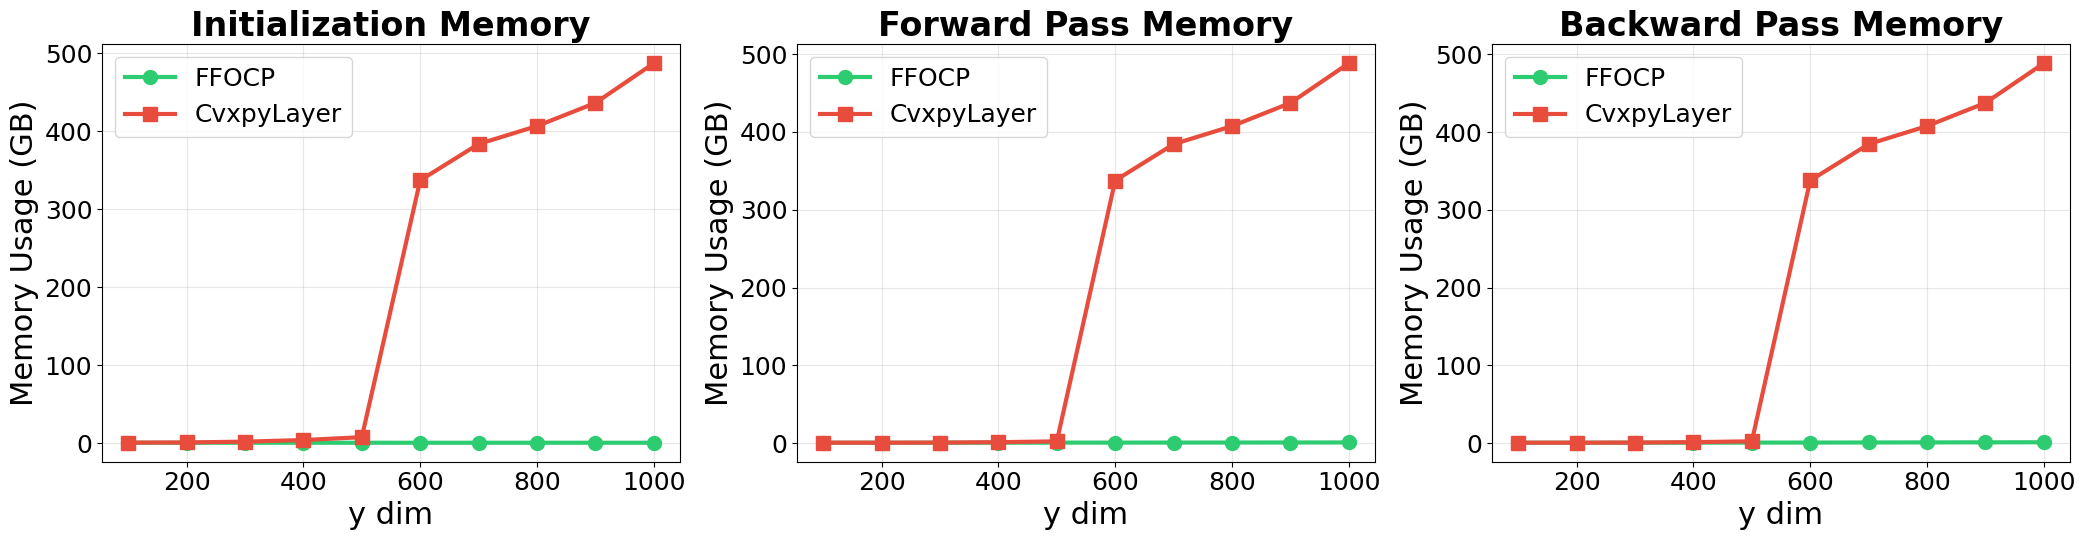

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))

color_ffocp = '#2ecc71'
color_cvxpy = '#e74c3c'

axes[0].plot(YDIM_LIST, df_ffocp['init_peak_rss_gb'].values, 'o-', 
             color=color_ffocp, linewidth=3, markersize=10, label='FFOCP')
axes[0].plot(YDIM_LIST, df_cvxpy['init_peak_rss_gb'].values, 's-', 
             color=color_cvxpy, linewidth=3, markersize=10, label='CvxpyLayer')
axes[0].set_xlabel('y dim', fontsize=22)
axes[0].set_ylabel('Memory Usage (GB)', fontsize=22)
axes[0].set_title('Initialization Memory', fontsize=24, fontweight='bold')
axes[0].legend(fontsize=18)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks([200, 400, 600, 800, 1000])
axes[0].tick_params(axis='both', labelsize=18)

axes[1].plot(YDIM_LIST, df_ffocp['forward_peak_rss_gb'].values, 'o-', 
             color=color_ffocp, linewidth=3, markersize=10, label='FFOCP')
axes[1].plot(YDIM_LIST, df_cvxpy['forward_peak_rss_gb'].values, 's-', 
             color=color_cvxpy, linewidth=3, markersize=10, label='CvxpyLayer')
axes[1].set_xlabel('y dim', fontsize=22)
axes[1].set_ylabel('Memory Usage (GB)', fontsize=22)
axes[1].set_title('Forward Pass Memory', fontsize=24, fontweight='bold')
axes[1].legend(fontsize=18)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks([200, 400, 600, 800, 1000])
axes[1].tick_params(axis='both', labelsize=18)

axes[2].plot(YDIM_LIST, df_ffocp['backward_peak_rss_gb'].values, 'o-', 
             color=color_ffocp, linewidth=3, markersize=10, label='FFOCP')
axes[2].plot(YDIM_LIST, df_cvxpy['backward_peak_rss_gb'].values, 's-', 
             color=color_cvxpy, linewidth=3, markersize=10, label='CvxpyLayer')
axes[2].set_xlabel('y dim', fontsize=22)
axes[2].set_ylabel('Memory Usage (GB)', fontsize=22)
axes[2].set_title('Backward Pass Memory', fontsize=24, fontweight='bold')
axes[2].legend(fontsize=18)
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks([200, 400, 600, 800, 1000])
axes[2].tick_params(axis='both', labelsize=18)

# plt.suptitle(f'Peak RSS Memory Comparison (batch_size={BATCH_SIZE})', 
#              fontsize=26, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('peakrss_vs_ydim_memory.pdf', dpi=300, bbox_inches='tight')
plt.show()

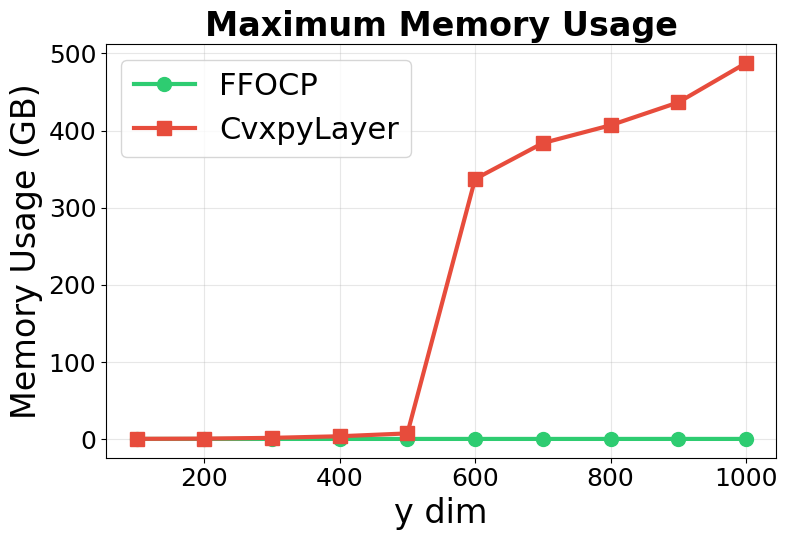

In [22]:
fig, ax = plt.subplots(figsize=(8, 5.5))

color_ffocp = '#2ecc71'
color_cvxpy = '#e74c3c'

ax.plot(YDIM_LIST, df_ffocp['init_peak_rss_gb'].values, 'o-', 
        color=color_ffocp, linewidth=3, markersize=10, label='FFOCP')
ax.plot(YDIM_LIST, df_cvxpy['init_peak_rss_gb'].values, 's-', 
        color=color_cvxpy, linewidth=3, markersize=10, label='CvxpyLayer')
ax.set_xlabel('y dim', fontsize=24)
ax.set_ylabel('Memory Usage (GB)', fontsize=24)
ax.set_title('Maximum Memory Usage', fontsize=24, fontweight='bold')
ax.legend(fontsize=22)
ax.grid(True, alpha=0.3)
ax.set_xticks([200, 400, 600, 800, 1000])
ax.tick_params(axis='both', labelsize=18)

plt.tight_layout()
plt.savefig('peakrss_max_memory.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Visualization: Execution Time vs ydim

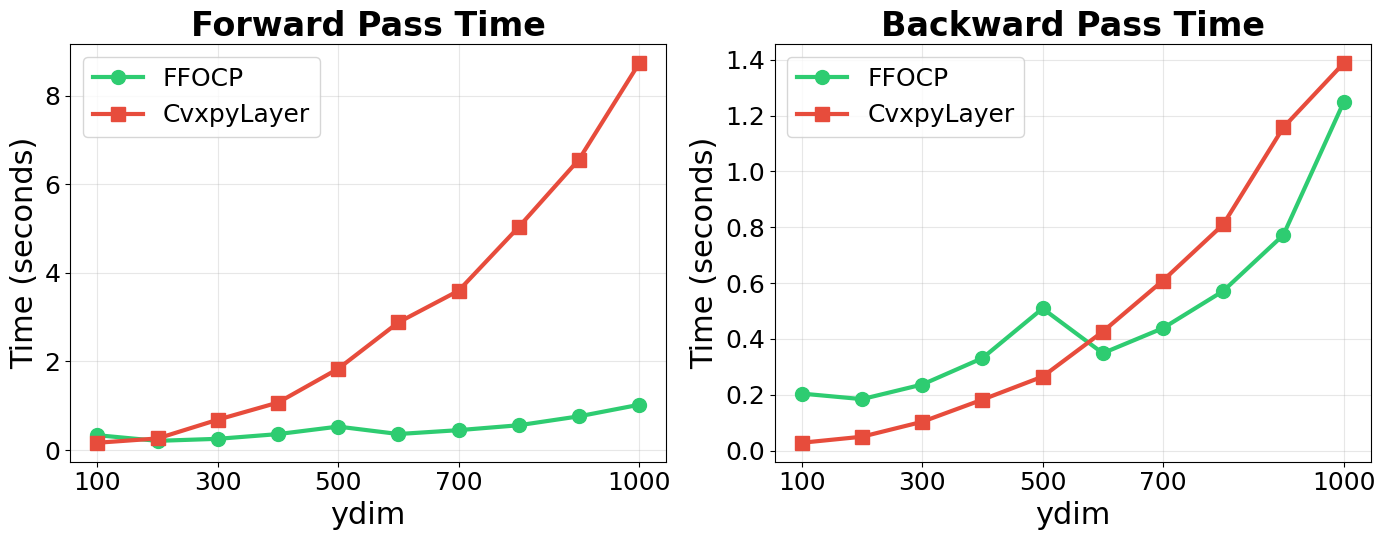

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(YDIM_LIST, df_ffocp['forward_time'].values, 'o-', 
             color=color_ffocp, linewidth=3, markersize=10, label='FFOCP')
axes[0].plot(YDIM_LIST, df_cvxpy['forward_time'].values, 's-', 
             color=color_cvxpy, linewidth=3, markersize=10, label='CvxpyLayer')
axes[0].set_xlabel('ydim', fontsize=22)
axes[0].set_ylabel('Time (seconds)', fontsize=22)
axes[0].set_title('Forward Pass Time', fontsize=24, fontweight='bold')
axes[0].legend(fontsize=18)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks([100, 300, 500, 700, 1000])
axes[0].tick_params(axis='both', labelsize=18)

axes[1].plot(YDIM_LIST, df_ffocp['backward_time'].values, 'o-', 
             color=color_ffocp, linewidth=3, markersize=10, label='FFOCP')
axes[1].plot(YDIM_LIST, df_cvxpy['backward_time'].values, 's-', 
             color=color_cvxpy, linewidth=3, markersize=10, label='CvxpyLayer')
axes[1].set_xlabel('ydim', fontsize=22)
axes[1].set_ylabel('Time (seconds)', fontsize=22)
axes[1].set_title('Backward Pass Time', fontsize=24, fontweight='bold')
axes[1].legend(fontsize=18)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks([100, 300, 500, 700, 1000])
axes[1].tick_params(axis='both', labelsize=18)

# plt.suptitle(f'Execution Time Comparison (batch_size={BATCH_SIZE})', 
#              fontsize=26, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('peakrss_vs_ydim_time.pdf', dpi=300, bbox_inches='tight')
plt.show()